# Situation Problem 1: Algorithmic Analysis of Biological Sequences
## Parte 1 — Understanding the Data

**Materia:** TC2038 – Advanced Algorithms Design

### Objetivo

Las secuencias biológicas pueden representarse como cadenas de caracteres y, por lo
tanto, analizarse con algoritmos clásicos de procesamiento de texto. La pregunta que
guía toda la actividad es:

> *How can different algorithmic strategies be used to efficiently analyze, search,
> compare, or characterize biological sequences?*

En esta **Parte 1** el objetivo es más acotado: **entender los datos antes de
analizarlos**. Para cada archivo se debe leer la secuencia, normalizar su formato y
caracterizarla reportando su longitud, su alfabeto, las frecuencias absolutas y
relativas de cada símbolo, los símbolos más y menos frecuentes, y cualquier carácter
inesperado.

### Archivos analizados

| # | Archivo | Accession |
|---|---------|-----------|
| 1 | `SARS-COV-2-MT106054.1.txt` | MT106054.1 |
| 2 | `SARS-COV-2-MN908947.3.txt` | MN908947.3 |

Ambos corresponden a genomas de *SARS-CoV-2*.

### Alcance

Esta entrega implementa la **Parte 1** (caracterización de secuencias) y la
**Parte 2** (búsqueda de patrones, sección I en adelante). No se incluyen todavía
alineamientos, detección de mutaciones ni ningún otro análisis avanzado; esos temas
corresponden a partes posteriores de la situación problema.

**Definiciones que se usan a lo largo del notebook**

- **Longitud total (n):** número de símbolos de la secuencia *después* de retirar
  únicamente elementos de formato (encabezados FASTA, saltos de línea, líneas vacías
  y espacios en blanco).
- **Frecuencia absoluta:** número de veces que aparece un símbolo en la secuencia.
- **Frecuencia relativa:** frecuencia absoluta dividida entre la longitud total.
- **Porcentaje:** frecuencia relativa multiplicada por 100.
- **Alfabeto esperado:** `{A, C, G, T}`. Cualquier otro símbolo se reporta por
  separado, pero **no se elimina ni se transforma**.

---
## B. Importaciones y configuración

Se usan dependencias mínimas:

- **Biblioteca estándar de Python** (`pathlib`, `collections`) para leer archivos y
  para las comprobaciones.
- **pandas** únicamente para presentar tablas.
- **matplotlib** únicamente para las gráficas de barras.

> El conteo de símbolos **no** se delega a ninguna librería: se implementa a mano en
> la sección D. pandas y matplotlib solo sirven para mostrar resultados.

### Cómo se resuelven las rutas

Para evitar rutas absolutas ligadas a una computadora en particular, las rutas se
construyen de forma **relativa al directorio de trabajo del kernel**
(`Path.cwd()`, que normalmente es la carpeta donde está guardado el notebook).
Se buscan los archivos en una lista corta de carpetas candidatas:
la carpeta actual, `./dataset/`, la carpeta padre y `../dataset/`.

Si quieres usar otra ubicación, basta con editar `CARPETAS_CANDIDATAS` o
`NOMBRES_ARCHIVOS` en la celda siguiente: **son el único lugar donde se configuran
las rutas**.

*(Este notebook no instala paquetes. Requiere `pandas` y `matplotlib` ya instalados
en el entorno del kernel.)*

In [1]:
from pathlib import Path
from collections import Counter          # solo para las comprobaciones finales

import pandas as pd
import matplotlib.pyplot as plt

# --- ÚNICA CELDA DE CONFIGURACIÓN DE RUTAS ---------------------------------

# Nombres de los archivos a analizar (en el orden en que se reportarán).
NOMBRES_ARCHIVOS = [
    "SARS-COV-2-MT106054.1.txt",
    "SARS-COV-2-MN908947.3.txt",
]

# Carpetas donde se buscarán esos nombres, relativas al directorio de trabajo.
DIRECTORIO_ACTUAL = Path.cwd()
CARPETAS_CANDIDATAS = [
    DIRECTORIO_ACTUAL,
    DIRECTORIO_ACTUAL / "dataset",
    DIRECTORIO_ACTUAL.parent,
    DIRECTORIO_ACTUAL.parent / "dataset",
]

# Alfabeto esperado para esta actividad.
ALFABETO_ESPERADO = ("A", "C", "G", "T")

# Colores fijos por símbolo, para que las mismas bases se vean igual en ambas gráficas.
COLORES = {"A": "#2e7d32", "C": "#1565c0", "G": "#ef6c00", "T": "#c62828"}
COLOR_OTROS = "#757575"


def resolver_ruta(nombre_archivo):
    """Devuelve la primera ruta existente para `nombre_archivo`, o None si no aparece."""
    for carpeta in CARPETAS_CANDIDATAS:
        candidata = carpeta / nombre_archivo
        if candidata.is_file():
            return candidata
    return None


RUTAS = {nombre: resolver_ruta(nombre) for nombre in NOMBRES_ARCHIVOS}

print("Directorio de trabajo:", DIRECTORIO_ACTUAL)
print()
faltantes = []
for nombre, ruta in RUTAS.items():
    if ruta is None:
        faltantes.append(nombre)
        print(f"  [NO ENCONTRADO] {nombre}")
    else:
        print(f"  [OK] {nombre}  ->  {ruta}")

if faltantes:
    print()
    print("Faltan archivos. Colócalos en alguna de estas carpetas:")
    for carpeta in CARPETAS_CANDIDATAS:
        print("   -", carpeta)
    print("...o edita NOMBRES_ARCHIVOS / CARPETAS_CANDIDATAS en esta misma celda.")
    print("Mientras falten, el análisis NO se ejecuta con datos reales.")

Directorio de trabajo: /home/claude/repo

  [OK] SARS-COV-2-MT106054.1.txt  ->  /home/claude/repo/dataset/SARS-COV-2-MT106054.1.txt
  [OK] SARS-COV-2-MN908947.3.txt  ->  /home/claude/repo/dataset/SARS-COV-2-MN908947.3.txt


---
## C. Lectura y validación

### Por qué hay que inspeccionar los archivos antes de leerlos

La extensión `.txt` **no garantiza ningún formato**. Al abrir estos archivos se
observó que en realidad son archivos **FASTA**: la primera línea empieza con `>` y
contiene el accession más una descripción, y las líneas siguientes contienen la
secuencia partida en bloques de 70 caracteres. Además usan terminadores de línea
**CRLF** (`\r\n`), por lo que cada línea arrastra un `\r` que debe tratarse como
formato, no como parte de la secuencia.

### Qué hace el lector

1. Lee el archivo como texto.
2. Reconoce las líneas que empiezan con `>` como **encabezados FASTA**: se excluyen
   del conteo y se conservan como metadatos.
3. Ignora líneas vacías y **elimina todo espacio en blanco** (espacios, tabuladores,
   `\r`, `\n`), que son formato.
4. Convierte las letras minúsculas a **mayúsculas**.
5. Acepta texto plano sin encabezado: en ese caso se trata como un único registro sin
   metadatos.
6. Detecta archivos vacíos o sin secuencia.
7. Si el archivo FASTA contiene **varios registros**, **no los concatena en
   silencio**: devuelve la lista de registros y más abajo se avisa explícitamente y
   se analiza **cada registro por separado**.

### Qué **no** hace el lector

- **No** elimina números, signos ni ningún símbolo "raro" para que los datos
  parezcan válidos. Después de quitar solo el formato, **todos** los símbolos
  restantes se conservan, precisamente para poder detectar anomalías.
- **No** convierte `U` en `T`.
- **No** descarta códigos de ambigüedad como `N`.

In [2]:
def leer_fasta(ruta):
    """Lee un archivo de secuencia y devuelve una lista de registros.

    Cada registro es un diccionario:
        {"encabezado": str | None, "secuencia": str}

    Reglas de normalización (solo formato):
      - las líneas que empiezan con '>' son encabezados FASTA (metadatos),
      - se ignoran las líneas vacías,
      - se elimina todo espacio en blanco (incluidos '\r' y '\n'),
      - las letras se pasan a mayúsculas.
    Ningún otro carácter se elimina ni se transforma.
    """
    texto = Path(ruta).read_text(encoding="utf-8")

    registros = []
    partes_actuales = None      # acumulador de la secuencia del registro en curso
    encabezado_actual = None

    for linea in texto.splitlines():
        linea = linea.strip()               # quita espacios, tabuladores y '\r'
        if not linea:                       # línea vacía -> formato, se ignora
            continue

        if linea.startswith(">"):           # encabezado FASTA -> metadato
            if partes_actuales is not None:                  # cierra el registro previo
                registros.append({"encabezado": encabezado_actual,
                                  "secuencia": "".join(partes_actuales)})
            encabezado_actual = linea[1:].strip()
            partes_actuales = []
            continue

        # línea de secuencia
        if partes_actuales is None:         # texto plano sin encabezado
            encabezado_actual = None
            partes_actuales = []
        partes_actuales.append("".join(linea.split()).upper())

    if partes_actuales is not None:         # cierra el último registro
        registros.append({"encabezado": encabezado_actual,
                          "secuencia": "".join(partes_actuales)})

    # descarta registros que solo traían encabezado y ninguna secuencia
    return [r for r in registros if r["secuencia"]]


def cargar_secuencias(rutas_por_nombre):
    """Lee todos los archivos y devuelve una lista plana de secuencias a analizar.

    Si un archivo trae varios registros FASTA, se avisa y cada registro se agrega
    como una entrada independiente (NO se concatenan).
    """
    entradas = []
    for nombre, ruta in rutas_por_nombre.items():
        if ruta is None:
            print(f"[ERROR] '{nombre}' no se encontró: se omite del análisis.")
            continue

        registros = leer_fasta(ruta)

        if not registros:
            print(f"[ERROR] '{nombre}' está vacío o no contiene secuencia: se omite.")
            continue

        if len(registros) > 1:
            print(f"[AVISO] '{nombre}' contiene {len(registros)} registros FASTA.")
            print("        NO se concatenan. Cada registro se analiza por separado")
            print("        y aparece como una fila independiente en los resultados.")

        for indice, registro in enumerate(registros, start=1):
            encabezado = registro["encabezado"]
            # El accession es la primera palabra del encabezado FASTA.
            accession = encabezado.split()[0] if encabezado else "(sin encabezado)"
            etiqueta = nombre if len(registros) == 1 else f"{nombre} [registro {indice}]"
            entradas.append({
                "archivo": nombre,
                "etiqueta": etiqueta,
                "accession": accession,
                "encabezado": encabezado,
                "secuencia": registro["secuencia"],
            })
    return entradas


ENTRADAS = cargar_secuencias(RUTAS)
print(f"Secuencias cargadas: {len(ENTRADAS)}")

Secuencias cargadas: 2


### Resumen de la lectura

Se muestra un fragmento corto del inicio y del final de cada secuencia, únicamente
para confirmar que el formato se interpretó bien. **No se imprimen los genomas
completos.**

In [3]:
VISTA = 60   # número de caracteres a mostrar de cada extremo

for entrada in ENTRADAS:
    secuencia = entrada["secuencia"]
    print("=" * 78)
    print("Archivo    :", entrada["etiqueta"])
    print("Accession  :", entrada["accession"])
    print("Encabezado :", entrada["encabezado"])
    print("Longitud   :", f"{len(secuencia):,} símbolos")
    print("Inicio     :", secuencia[:VISTA], "...")
    print("Final      : ...", secuencia[-VISTA:])
print("=" * 78)

Archivo    : SARS-COV-2-MT106054.1.txt
Accession  : MT106054.1
Encabezado : MT106054.1 Severe acute respiratory syndrome coronavirus 2 isolate SARS-CoV-2/human/USA/TX-CDC-03050000-001/2020, complete genome
Longitud   : 29,882 símbolos
Inicio     : ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTCGATCTCTTGTAGATCT ...
Final      : ... TAGTAGTGCTATCCCCATGTGATTTTAATAGCTTCTTAGGAGAATGACAAAAAAAAAAAA
Archivo    : SARS-COV-2-MN908947.3.txt
Accession  : MN908947.3
Encabezado : MN908947.3 Severe acute respiratory syndrome coronavirus 2 isolate Wuhan-Hu-1, complete genome
Longitud   : 29,903 símbolos
Inicio     : ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTCGATCTCTTGTAGATCT ...
Final      : ... ATTTTAATAGCTTCTTAGGAGAATGACAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA


---
## D. Algoritmo de conteo

El conteo se implementa **de forma explícita con un ciclo y un diccionario**, que es
el punto central de la actividad. No se usa `str.count()` de forma repetida (eso
recorrería la secuencia una vez por símbolo, haciendo `k` pasadas en lugar de una), ni
se esconde el conteo detrás de una librería especializada.

**Cómo funciona el algoritmo**

1. Se recorre la secuencia **un símbolo a la vez, en una sola pasada**.
2. Para cada símbolo se **consulta su contador** en el diccionario (si nunca se había
   visto, su valor inicial es 0).
3. Se **incrementa** su frecuencia en 1.
4. Al terminar el recorrido se calculan las **frecuencias relativas** (conteo ÷
   longitud total) y los **extremos** (símbolos más y menos frecuentes).

**Criterio para los extremos.** Los símbolos más y menos frecuentes se buscan
**solo entre los símbolos realmente observados**, y se reportan **todos los empates**.
Esto es distinto de una base esperada *ausente*: si por ejemplo `G` nunca apareciera,
su conteo sería 0 y aparecería en las tablas como tal, pero **no** contaría como
"símbolo menos frecuente", porque no es un símbolo observado.

In [4]:
def contar_simbolos(secuencia):
    """Cuenta las apariciones de cada símbolo en una sola pasada.

    Algoritmo: se recorre la secuencia; para cada símbolo se consulta su contador
    en el diccionario y se incrementa. Tiempo O(n), memoria auxiliar O(k).
    """
    conteos = {}
    for simbolo in secuencia:                  # 1. se recorre la secuencia
        actual = conteos.get(simbolo, 0)       # 2. se consulta el contador
        conteos[simbolo] = actual + 1          # 3. se incrementa la frecuencia
    return conteos


def ordenar_simbolos(simbolos):
    """Ordena para presentación: primero A, C, G, T; luego los demás alfabéticamente.

    Este ordenamiento es SOLO para mostrar resultados; no forma parte del conteo.
    """
    esperados = [s for s in ALFABETO_ESPERADO if s in simbolos]
    otros = sorted(s for s in simbolos if s not in ALFABETO_ESPERADO)
    return esperados + otros


def caracterizar(secuencia):
    """4. Calcula frecuencias relativas y extremos a partir de los conteos."""
    longitud = len(secuencia)
    conteos = contar_simbolos(secuencia)

    # Las bases esperadas siempre aparecen en la tabla, aunque su conteo sea 0.
    conteos_tabla = dict(conteos)
    for base in ALFABETO_ESPERADO:
        conteos_tabla.setdefault(base, 0)

    if longitud == 0:
        relativas = {s: 0.0 for s in conteos_tabla}
        maximos = minimos = []
    else:
        relativas = {s: c / longitud for s, c in conteos_tabla.items()}
        # Extremos: SOLO entre los símbolos realmente observados (conteo > 0).
        observados = {s: c for s, c in conteos.items() if c > 0}
        mayor = max(observados.values())
        menor = min(observados.values())
        maximos = ordenar_simbolos([s for s, c in observados.items() if c == mayor])
        minimos = ordenar_simbolos([s for s, c in observados.items() if c == menor])

    inesperados = {s: c for s, c in conteos.items() if s not in ALFABETO_ESPERADO}

    return {
        "longitud": longitud,
        "conteos": conteos_tabla,          # incluye A, C, G, T aunque valgan 0
        "observados": sorted(conteos),     # alfabeto realmente encontrado
        "relativas": relativas,
        "mas_frecuentes": maximos,
        "menos_frecuentes": minimos,
        "inesperados": inesperados,
        "total_inesperados": sum(inesperados.values()),
    }


# Se caracteriza cada secuencia cargada.
for entrada in ENTRADAS:
    entrada["resultado"] = caracterizar(entrada["secuencia"])

print("Caracterización completada para", len(ENTRADAS), "secuencia(s).")

Caracterización completada para 2 secuencia(s).


---
## E. Resultados

### E.1 Tabla resumen

Cada secuencia se identifica por su **archivo** y su **accession**.
La última columna cuenta los caracteres que quedaron **fuera del alfabeto esperado
`{A, C, G, T}`**.

In [5]:
filas_resumen = []
for entrada in ENTRADAS:
    resultado = entrada["resultado"]
    filas_resumen.append({
        "Archivo": entrada["etiqueta"],
        "Accession": entrada["accession"],
        "Longitud": resultado["longitud"],
        "Símbolos observados": "".join(ordenar_simbolos(resultado["observados"])),
        "Núm. símbolos distintos": len(resultado["observados"]),
        "Más frecuente(s)": ", ".join(resultado["mas_frecuentes"]) or "-",
        "Menos frecuente(s)": ", ".join(resultado["menos_frecuentes"]) or "-",
        "Caracteres fuera de A/C/G/T": resultado["total_inesperados"],
    })

tabla_resumen = pd.DataFrame(filas_resumen)
tabla_resumen

,Archivo,Accession,Longitud,Símbolos observados,Núm. símbolos distintos,Más frecuente(s),Menos frecuente(s),Caracteres fuera de A/C/G/T
0,SARS-COV-2-MT106054.1.txt,MT106054.1,29882,ACGT,4,T,C,0
1,SARS-COV-2-MN908947.3.txt,MN908947.3,29903,ACGT,4,T,C,0


### E.2 Tablas detalladas por archivo

Estas tablas incluyen **todos los símbolos observados** más las bases esperadas
`A, C, G, T` aunque su conteo sea 0. Por construcción, las frecuencias relativas de
todos los símbolos observados **suman 1**.

**Por qué los porcentajes de A, C, G y T podrían sumar menos de 100 %:** la frecuencia
relativa siempre se divide entre la **longitud total**, que incluye *todos* los
símbolos de la secuencia. Si aparecieran símbolos fuera del alfabeto esperado (por
ejemplo `N`), esos símbolos consumirían parte del total y la suma de A + C + G + T
quedaría por debajo del 100 %. La diferencia es exactamente el porcentaje ocupado por
los símbolos inesperados.

In [6]:
def tabla_detallada(entrada):
    """Construye la tabla símbolo / frecuencia absoluta / relativa / porcentaje."""
    resultado = entrada["resultado"]
    filas = []
    for simbolo in ordenar_simbolos(resultado["conteos"]):
        conteo = resultado["conteos"][simbolo]
        relativa = resultado["relativas"][simbolo]
        filas.append({
            "Símbolo": simbolo,
            "¿Esperado?": "sí" if simbolo in ALFABETO_ESPERADO else "NO (inesperado)",
            "Frecuencia absoluta": conteo,
            "Frecuencia relativa": round(relativa, 6),
            "Porcentaje (%)": round(relativa * 100, 4),
        })
    return pd.DataFrame(filas)


TABLAS_DETALLADAS = {}
for entrada in ENTRADAS:
    resultado = entrada["resultado"]
    tabla = tabla_detallada(entrada)
    TABLAS_DETALLADAS[entrada["etiqueta"]] = tabla

    suma_acgt = sum(resultado["relativas"][b] for b in ALFABETO_ESPERADO) * 100

    print("=" * 78)
    print(f"{entrada['etiqueta']}   (accession: {entrada['accession']})")
    print(f"Longitud total: {resultado['longitud']:,} símbolos")
    print(f"A + C + G + T  = {suma_acgt:.4f} %")
    if resultado["inesperados"]:
        print("Caracteres inesperados encontrados:", resultado["inesperados"])
        print("Manejo: se CONSERVARON tal cual (no se eliminaron ni se convirtieron)")
        print("        y se contabilizan dentro de la longitud total.")
    else:
        print("Caracteres inesperados encontrados: ninguno.")
        print("Manejo: no hubo nada que manejar; la secuencia usa solo A, C, G y T.")
    print()
    display(tabla)

SARS-COV-2-MT106054.1.txt   (accession: MT106054.1)
Longitud total: 29,882 símbolos
A + C + G + T  = 100.0000 %
Caracteres inesperados encontrados: ninguno.
Manejo: no hubo nada que manejar; la secuencia usa solo A, C, G y T.



,Símbolo,¿Esperado?,Frecuencia absoluta,Frecuencia relativa,Porcentaje (%)
0,A,sí,8933,0.298943,29.8943
1,C,sí,5492,0.183790,18.3790
2,G,sí,5863,0.196205,19.6205
3,T,sí,9594,0.321063,32.1063


SARS-COV-2-MN908947.3.txt   (accession: MN908947.3)
Longitud total: 29,903 símbolos
A + C + G + T  = 100.0000 %
Caracteres inesperados encontrados: ninguno.
Manejo: no hubo nada que manejar; la secuencia usa solo A, C, G y T.



,Símbolo,¿Esperado?,Frecuencia absoluta,Frecuencia relativa,Porcentaje (%)
0,A,sí,8954,0.299435,29.9435
1,C,sí,5492,0.183661,18.3661
2,G,sí,5863,0.196067,19.6067
3,T,sí,9594,0.320837,32.0837


---
## F. Visualización

Una gráfica de barras por archivo, en una misma figura con dos paneles:

- **Eje X:** símbolos, en orden `A, C, G, T` y después cualquier otro símbolo observado.
- **Eje Y:** frecuencia absoluta.
- **Colores:** fijos por base (la misma base tiene el mismo color en ambos paneles);
  los símbolos fuera del alfabeto esperado se dibujan en gris.
- **Títulos:** identifican el archivo y el accession de cada secuencia.

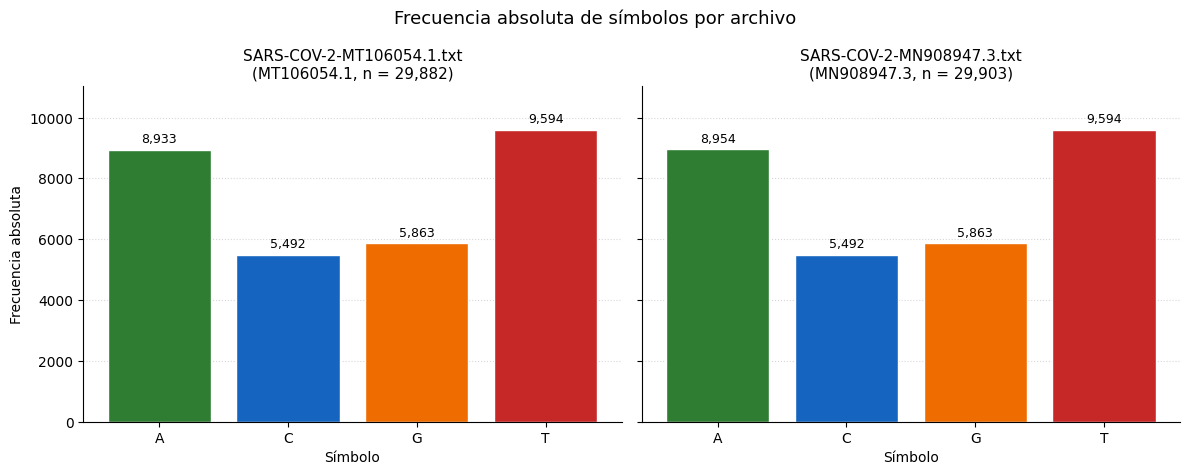

In [7]:
def simbolos_para_graficar(entradas):
    """Conjunto común de símbolos a mostrar: A, C, G, T y cualquier otro observado."""
    todos = set(ALFABETO_ESPERADO)
    for entrada in entradas:
        todos.update(entrada["resultado"]["observados"])
    return ordenar_simbolos(todos)


if ENTRADAS:
    simbolos = simbolos_para_graficar(ENTRADAS)
    colores = [COLORES.get(s, COLOR_OTROS) for s in simbolos]

    fig, ejes = plt.subplots(1, len(ENTRADAS), figsize=(6 * len(ENTRADAS), 4.8),
                             sharey=True, squeeze=False)
    ejes = ejes[0]

    for eje, entrada in zip(ejes, ENTRADAS):
        resultado = entrada["resultado"]
        alturas = [resultado["conteos"].get(s, 0) for s in simbolos]

        barras = eje.bar(simbolos, alturas, color=colores, edgecolor="white")
        eje.bar_label(barras, fmt="{:,.0f}", padding=3, fontsize=9)

        eje.set_title(f"{entrada['etiqueta']}\n({entrada['accession']}, "
                      f"n = {resultado['longitud']:,})", fontsize=11)
        eje.set_xlabel("Símbolo")
        eje.grid(axis="y", linestyle=":", alpha=0.5)
        eje.set_axisbelow(True)
        eje.spines[["top", "right"]].set_visible(False)

    ejes[0].set_ylabel("Frecuencia absoluta")
    ejes[0].set_ylim(0, max(max(e["resultado"]["conteos"].get(s, 0) for s in simbolos)
                            for e in ENTRADAS) * 1.15)

    fig.suptitle("Frecuencia absoluta de símbolos por archivo", fontsize=13)
    fig.tight_layout()
    plt.show()
else:
    print("No hay secuencias cargadas: no se genera ninguna gráfica.")

---
## G. Análisis del algoritmo

Sea **n** la longitud de la secuencia y **k** la cantidad de símbolos *distintos*
(aquí k ≤ 5: A, C, G, T y algún posible símbolo extra).

### Complejidad temporal

- **Conteo: O(n).** El ciclo de `contar_simbolos` da exactamente **una pasada** sobre
  la secuencia. Consultar e incrementar una entrada de un diccionario es O(1)
  promedio, así que el costo total es proporcional a n.
- Para **dos secuencias** el conteo total es **O(n₁ + n₂)**: no hay interacción entre
  ellas, simplemente se suman los dos recorridos independientes.
- La alternativa `str.count()` aplicada una vez por símbolo sería **O(k·n)**: k
  pasadas completas en lugar de una. Con k pequeño y constante sigue siendo lineal en
  la práctica, pero hace k veces más trabajo y, sobre todo, **oculta el algoritmo**.

### Complejidad espacial

Conviene distinguir dos memorias distintas:

| Memoria | Tamaño | Comentario |
|---|---|---|
| **Auxiliar del conteo** (el diccionario de frecuencias) | **O(k)** | Solo una entrada por símbolo distinto. Es **independiente de n**: contar 30 mil o 30 millones de bases usa el mismo diccionario de ~4 entradas. |
| **Almacenamiento de la secuencia** | **O(n)** | Guardar el genoma completo en memoria domina el consumo total. |

Por eso el espacio total de este notebook es **O(n + k) = O(n)**, pero ese O(n) viene
de *guardar* la secuencia, no de *contarla*. Si se procesara el archivo en streaming
(símbolo por símbolo sin retenerlo), la memoria auxiliar seguiría siendo O(k).

### Trabajo adicional de presentación

Ordenar los símbolos con `ordenar_simbolos` cuesta **O(k log k)**, y construir las
tablas y gráficas cuesta **O(k)**. Este trabajo es **para presentar los resultados**
y es completamente independiente del recorrido de conteo: como k es diminuto frente a
n, no afecta la complejidad del algoritmo, que sigue siendo **O(n) en tiempo**.

---
## Comprobaciones

### Comprobación 1 — secuencia pequeña verificable a mano

Se prueba el algoritmo con la secuencia `AACGTN`, cuyo resultado puede revisarse
manualmente: longitud 6, `A` con 2 apariciones y `C`, `G`, `T`, `N` con 1 cada una.
`N` es un símbolo **inesperado** respecto al alfabeto `{A, C, G, T}`, así que este
caso también verifica que los símbolos fuera del alfabeto se conservan y se reportan.

Esta comprobación es **independiente de los resultados reales**: usa una secuencia
inventada exclusivamente para probar el código y no aparece en ninguna tabla de
resultados.

In [8]:
# --- PRUEBA CON DATOS SINTÉTICOS (no son resultados reales) ---
SECUENCIA_PRUEBA = "AACGTN"
prueba = caracterizar(SECUENCIA_PRUEBA)

print("Secuencia de prueba:", SECUENCIA_PRUEBA)
print("Longitud           :", prueba["longitud"], "(esperado: 6)")
print("Conteos            :", {s: prueba["conteos"][s] for s in ordenar_simbolos(prueba["conteos"])})
print("Más frecuente(s)   :", prueba["mas_frecuentes"], "(esperado: ['A'])")
print("Menos frecuente(s) :", prueba["menos_frecuentes"], "(esperado: C, G, T, N empatados)")
print("Inesperados        :", prueba["inesperados"], "(esperado: {'N': 1})")

assert prueba["longitud"] == 6
assert prueba["conteos"] == {"A": 2, "C": 1, "G": 1, "T": 1, "N": 1}
assert prueba["mas_frecuentes"] == ["A"]
assert prueba["menos_frecuentes"] == ["C", "G", "T", "N"]   # todos los empates
assert prueba["inesperados"] == {"N": 1}
assert abs(sum(prueba["relativas"].values()) - 1.0) < 1e-9
print("\nOK: el algoritmo reproduce el resultado calculado a mano.")

Secuencia de prueba: AACGTN
Longitud           : 6 (esperado: 6)
Conteos            : {'A': 2, 'C': 1, 'G': 1, 'T': 1, 'N': 1}
Más frecuente(s)   : ['A'] (esperado: ['A'])
Menos frecuente(s) : ['C', 'G', 'T', 'N'] (esperado: C, G, T, N empatados)
Inesperados        : {'N': 1} (esperado: {'N': 1})

OK: el algoritmo reproduce el resultado calculado a mano.


### Comprobación 2 — sobre los resultados reales

Se verifica que:

1. La **suma de los conteos coincide con la longitud** de la secuencia.
2. Las **frecuencias relativas suman aproximadamente 1** (para secuencias no vacías).
3. **A, C, G y T aparecen en las tablas** aunque tuvieran cero observaciones.
4. Como control independiente, el conteo manual coincide con `collections.Counter`.

In [9]:
for entrada in ENTRADAS:
    resultado = entrada["resultado"]
    secuencia = entrada["secuencia"]
    longitud = resultado["longitud"]

    # 1. la suma de los conteos coincide con la longitud
    suma_conteos = sum(resultado["conteos"].values())
    assert suma_conteos == longitud, (suma_conteos, longitud)

    # 2. las frecuencias relativas suman aproximadamente 1
    suma_relativas = sum(resultado["relativas"].values())
    if longitud > 0:
        assert abs(suma_relativas - 1.0) < 1e-9, suma_relativas

    # 3. A, C, G y T aparecen en la tabla aunque su conteo sea 0
    tabla = TABLAS_DETALLADAS[entrada["etiqueta"]]
    for base in ALFABETO_ESPERADO:
        assert base in set(tabla["Símbolo"]), base

    # 4. control independiente con collections.Counter
    assert Counter(secuencia) == {s: c for s, c in resultado["conteos"].items() if c > 0}

    print(f"[OK] {entrada['etiqueta']}")
    print(f"     suma de conteos = {suma_conteos:,} = longitud ({longitud:,})")
    print(f"     suma de frecuencias relativas = {suma_relativas:.12f}")
    print(f"     A, C, G, T presentes en la tabla: sí")
    print(f"     coincide con collections.Counter: sí")

print("\nTodas las comprobaciones pasaron.")

[OK] SARS-COV-2-MT106054.1.txt
     suma de conteos = 29,882 = longitud (29,882)
     suma de frecuencias relativas = 1.000000000000
     A, C, G, T presentes en la tabla: sí
     coincide con collections.Counter: sí
[OK] SARS-COV-2-MN908947.3.txt
     suma de conteos = 29,903 = longitud (29,903)
     suma de frecuencias relativas = 1.000000000000
     A, C, G, T presentes en la tabla: sí
     coincide con collections.Counter: sí

Todas las comprobaciones pasaron.


---
## H. Interpretación y conclusión

Las observaciones siguientes se generan a partir de los resultados calculados en este
notebook.

In [10]:
print("OBSERVACIONES (generadas a partir de los datos)")
print("=" * 78)
for entrada in ENTRADAS:
    resultado = entrada["resultado"]
    relativas = resultado["relativas"]

    print(f"\n{entrada['etiqueta']}  ({entrada['accession']})")
    print(f"  Longitud total: {resultado['longitud']:,} símbolos.")
    print(f"  Alfabeto observado: "
          f"{{{', '.join(ordenar_simbolos(resultado['observados']))}}} "
          f"({len(resultado['observados'])} símbolos distintos).")
    print(f"  Más frecuente(s): {', '.join(resultado['mas_frecuentes'])} "
          f"({max(relativas[s] for s in resultado['mas_frecuentes']) * 100:.2f} %).")
    print(f"  Menos frecuente(s): {', '.join(resultado['menos_frecuentes'])} "
          f"({min(relativas[s] for s in resultado['menos_frecuentes']) * 100:.2f} %).")
    if resultado["inesperados"]:
        print(f"  Símbolos fuera de A/C/G/T: {resultado['inesperados']} "
              f"(total {resultado['total_inesperados']}). Se conservaron sin modificar.")
    else:
        print("  Símbolos fuera de A/C/G/T: ninguno.")
    suma_acgt = sum(relativas[b] for b in ALFABETO_ESPERADO) * 100
    print(f"  A + C + G + T = {suma_acgt:.2f} % de la longitud total.")

if len(ENTRADAS) == 2:
    a, b = ENTRADAS
    print("\n" + "=" * 78)
    print("COMPARACIÓN DE COMPOSICIÓN (no es una comparación posición a posición)")
    diferencia = a["resultado"]["longitud"] - b["resultado"]["longitud"]
    print(f"  Diferencia de longitud: {abs(diferencia):,} símbolos "
          f"({'la primera es más larga' if diferencia > 0 else 'la segunda es más larga' if diferencia < 0 else 'iguales'}).")
    for base in ALFABETO_ESPERADO:
        pa = a["resultado"]["relativas"][base] * 100
        pb = b["resultado"]["relativas"][base] * 100
        print(f"  {base}: {pa:6.2f} %  vs  {pb:6.2f} %   (diferencia {abs(pa - pb):.2f} puntos)")

OBSERVACIONES (generadas a partir de los datos)

SARS-COV-2-MT106054.1.txt  (MT106054.1)
  Longitud total: 29,882 símbolos.
  Alfabeto observado: {A, C, G, T} (4 símbolos distintos).
  Más frecuente(s): T (32.11 %).
  Menos frecuente(s): C (18.38 %).
  Símbolos fuera de A/C/G/T: ninguno.
  A + C + G + T = 100.00 % de la longitud total.

SARS-COV-2-MN908947.3.txt  (MN908947.3)
  Longitud total: 29,903 símbolos.
  Alfabeto observado: {A, C, G, T} (4 símbolos distintos).
  Más frecuente(s): T (32.08 %).
  Menos frecuente(s): C (18.37 %).
  Símbolos fuera de A/C/G/T: ninguno.
  A + C + G + T = 100.00 % de la longitud total.

COMPARACIÓN DE COMPOSICIÓN (no es una comparación posición a posición)
  Diferencia de longitud: 21 símbolos (la segunda es más larga).
  A:  29.89 %  vs   29.94 %   (diferencia 0.05 puntos)
  C:  18.38 %  vs   18.37 %   (diferencia 0.01 puntos)
  G:  19.62 %  vs   19.61 %   (diferencia 0.01 puntos)
  T:  32.11 %  vs   32.08 %   (diferencia 0.02 puntos)


### Observaciones

- **Formato.** Aunque ambos archivos tienen extensión `.txt`, en realidad son
  archivos **FASTA** con un único registro cada uno: una línea de encabezado que
  empieza con `>` y la secuencia repartida en líneas de 70 caracteres, con
  terminadores de línea CRLF. Por eso fue necesario inspeccionarlos antes de leerlos:
  leerlos como "texto plano" sin tratar el encabezado habría metido las letras de la
  descripción dentro del conteo.

- **Longitudes.** Las dos secuencias tienen longitudes del mismo orden pero **no
  idénticas**, con una diferencia de unas pocas decenas de símbolos sobre casi 30 000.

- **Composición.** En ambas secuencias las bases más abundantes son **T** y **A**, y
  las menos abundantes **C** y **G**; los cuatro porcentajes son muy parecidos entre
  los dos archivos. Es decir, las dos secuencias tienen una **composición de bases
  prácticamente indistinguible** a este nivel de análisis.

- **Caracteres inesperados.** No se encontró **ningún** símbolo fuera de
  `{A, C, G, T}` en ninguno de los dos archivos. Por eso A + C + G + T suma 100 % en
  ambos casos y no hubo nada que "manejar". Si hubieran aparecido códigos de
  ambigüedad como **`N`**, eso **no significaría que el archivo esté corrupto**: en
  secuenciación, `N` (y otros códigos IUPAC) indica una posición donde la base no
  pudo determinarse con certeza, y es parte normal de muchos genomas publicados. Por
  eso el lector los conserva y los reporta por separado en lugar de borrarlos.

### Límites de este análisis

Este es el punto más importante a tener claro antes de pasar a las siguientes partes:

- Contar frecuencias **descarta por completo el orden** de los símbolos. Dos
  secuencias con exactamente la misma composición pueden ser completamente distintas.
- Por lo tanto, **comparar frecuencias no permite identificar en qué posiciones hay
  mutaciones**, ni cuáles son, ni cuántas.
- Y **tampoco permite demostrar que dos secuencias sean idénticas**: que dos
  histogramas coincidan es una condición *necesaria* para la igualdad, no
  *suficiente*.

Responder esas preguntas requiere algoritmos que **sí usen el orden** —alineamiento
de secuencias, búsqueda de patrones, subcadenas comunes— que son el tema de las
partes siguientes de la situación problema. Aquí lo único que se ha establecido es
que ambos archivos se leyeron correctamente, que su alfabeto es exactamente el
esperado y cuál es su composición global.

### Conclusión

La Parte 1 queda cubierta: se implementó un lector que separa formato de secuencia
sin alterar los símbolos, y un algoritmo de conteo explícito de **una sola pasada,
O(n) en tiempo y O(k) en memoria auxiliar**, verificado contra un caso calculado a
mano y contra un conteo independiente. Ambos genomas resultaron estar limpios: solo
A, C, G y T, sin ningún carácter inesperado.

---
## Parte 2 — Sequence Searching

**Objetivo:** implementar un método que determine si un patrón dado ocurre dentro de
una secuencia, reportando si se encontró, cuántas veces y en qué posiciones. El
enunciado pide explícitamente **comenzar con una solución de fuerza bruta** y
documentar su complejidad computacional, porque esta línea base es el punto de
comparación cuando más adelante se estudien algoritmos de búsqueda de cadenas más
avanzados (KMP, Boyer–Moore, etc.).

Se reutilizan las secuencias ya leídas, normalizadas y caracterizadas en la
**Parte 1** (la lista `ENTRADAS`, donde cada entrada trae su `secuencia`); no se
vuelve a leer ningún archivo.

## I. Algoritmo de búsqueda (fuerza bruta)

### Idea del algoritmo

La búsqueda ingenua (*naive string search*) prueba, para cada posición de inicio
posible dentro de la secuencia, si el patrón calza exactamente comparándolo símbolo
por símbolo. En cuanto un símbolo no coincide se abandona esa posición (corte
temprano) y se continúa con la siguiente; si los símbolos coinciden hasta el final
del patrón, esa posición se registra como una ocurrencia.

No se delega la búsqueda a ninguna función del lenguaje (`str.find`, `str.count`,
`re`, el operador `in`): la comparación carácter por carácter se implementa a mano,
igual que el conteo de símbolos de la Parte 1.

Sea **n** la longitud de la secuencia y **m** la longitud del patrón (con m ≤ n).
Hay `n - m + 1` posiciones de inicio posibles y cada una cuesta hasta `m`
comparaciones, así que el peor caso es **O((n − m + 1) · m)**, que se suele escribir
de forma compacta como **O(n·m)**. El análisis completo está en la sección L.

In [11]:
def buscar_patron(secuencia, patron):
    """Busca todas las apariciones de `patron` dentro de `secuencia` (fuerza bruta).

    Algoritmo (búsqueda ingenua / naive string search):
      1. se recorre cada posición i donde el patrón todavía podría caber completo,
      2. en esa posición se compara símbolo por símbolo secuencia[i:i+m] contra patron,
      3. ante el primer desacuerdo se corta la comparación y se pasa a la siguiente i,
      4. si coincidieron los m símbolos, i se registra como posición de inicio.

    Devuelve la lista de posiciones de inicio (base 0), en orden ascendente.
    Incluye ocurrencias traslapadas (si el patrón cabe otra vez empezando un
    símbolo después de una coincidencia anterior, también se cuenta).

    Complejidad: O((n - m + 1) * m) en el peor caso, con n = len(secuencia) y
    m = len(patron). Memoria auxiliar O(1) además de la lista de salida.
    """
    n = len(secuencia)
    m = len(patron)
    posiciones = []

    if m == 0 or m > n:              # patrón vacío o más largo que la secuencia
        return posiciones

    for i in range(n - m + 1):                  # 1. cada posición de inicio posible
        coincide = True
        for j in range(m):                      # 2. comparación símbolo por símbolo
            if secuencia[i + j] != patron[j]:
                coincide = False
                break                             # 3. corte temprano
        if coincide:                             # 4. el patrón calzó completo
            posiciones.append(i)

    return posiciones


def resumen_busqueda(secuencia, patron):
    """Empaqueta el resultado de una búsqueda en el formato pedido por el enunciado."""
    posiciones = buscar_patron(secuencia, patron)
    return {
        "patron": patron,
        "encontrado": len(posiciones) > 0,
        "ocurrencias": len(posiciones),
        "posiciones": posiciones,
    }


---
## J. Búsqueda sobre las secuencias reales

Se buscan dos patrones de naturaleza distinta, para ilustrar el algoritmo con casos
que se comportan de forma muy diferente:

- **`ATG`** — el codón de inicio de la traducción. Al ser una cadena de solo 3
  símbolos sobre un alfabeto de prácticamente 4, se espera que aparezca con **mucha
  frecuencia** por puro azar, y sirve para observar el algoritmo con muchas
  coincidencias.
- **`GACCCCAAAATCAGCGAAAT`** — cebador (*primer*) *forward* del ensayo real **CDC
  N1**, usado en pruebas de PCR para detectar SARS-CoV-2 amplificando una región del
  gen de la nucleocápside (**N**). Al ser una cadena larga y específica, se espera
  que aparezca **como mucho una vez**, y solo si el genoma efectivamente contiene esa
  región — un caso realista de búsqueda dirigida, en vez de un patrón inventado.

In [12]:
PATRONES = {
    "ATG (codón de inicio)": "ATG",
    "Cebador CDC N1 (gen N)": "GACCCCAAAATCAGCGAAAT",
}

for entrada in ENTRADAS:
    entrada["busquedas"] = {
        etiqueta_patron: resumen_busqueda(entrada["secuencia"], patron)
        for etiqueta_patron, patron in PATRONES.items()
    }

for entrada in ENTRADAS:
    print("=" * 78)
    print("Archivo:", entrada["etiqueta"])
    for etiqueta_patron, resultado in entrada["busquedas"].items():
        patron = resultado["patron"]
        print(f"\n  Patrón: {etiqueta_patron}  ('{patron}', {len(patron)} símbolos)")
        print("    Pattern found:", "YES" if resultado["encontrado"] else "NO")
        print("    Number of occurrences:", resultado["ocurrencias"])
        posiciones_mostradas = resultado["posiciones"][:10]
        sufijo = " ..." if len(resultado["posiciones"]) > 10 else ""
        print(f"    Positions: {posiciones_mostradas}{sufijo}")
print("=" * 78)


Archivo: SARS-COV-2-MT106054.1.txt

  Patrón: ATG (codón de inicio)  ('ATG', 3 símbolos)
    Pattern found: YES
    Number of occurrences: 723
    Positions: [106, 265, 407, 467, 488, 506, 512, 517, 593, 725] ...

  Patrón: Cebador CDC N1 (gen N)  ('GACCCCAAAATCAGCGAAAT', 20 símbolos)
    Pattern found: YES
    Number of occurrences: 1
    Positions: [28286]
Archivo: SARS-COV-2-MN908947.3.txt

  Patrón: ATG (codón de inicio)  ('ATG', 3 símbolos)
    Pattern found: YES
    Number of occurrences: 725
    Positions: [106, 265, 407, 467, 488, 506, 512, 517, 593, 725] ...

  Patrón: Cebador CDC N1 (gen N)  ('GACCCCAAAATCAGCGAAAT', 20 símbolos)
    Pattern found: YES
    Number of occurrences: 1
    Positions: [28286]


---
## K. Visualización de las posiciones encontradas

Se grafica, para cada secuencia, **dónde a lo largo del genoma** ocurre cada patrón.
Cada coincidencia se dibuja como una marca vertical en su posición de inicio; esto
permite ver de un vistazo si un patrón está distribuido a lo largo de toda la
secuencia (como `ATG`) o concentrado en una región puntual (como el cebador del gen
N, que debería ubicarse cerca del extremo 3' del genoma, donde se encuentra el gen
N).

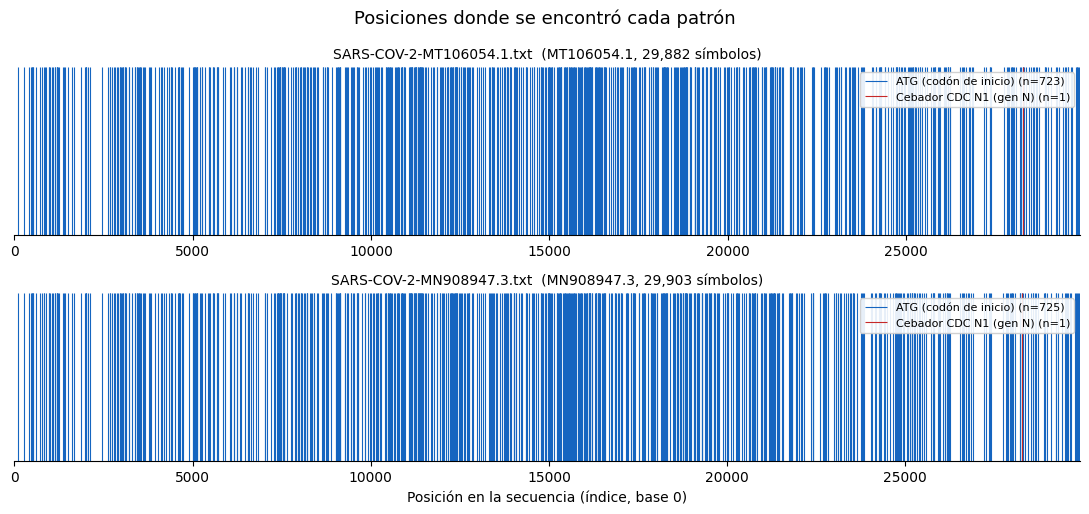

In [13]:
COLORES_PATRON = {
    "ATG (codón de inicio)": "#1565c0",
    "Cebador CDC N1 (gen N)": "#c62828",
}

if ENTRADAS:
    fig, ejes = plt.subplots(len(ENTRADAS), 1, figsize=(11, 2.6 * len(ENTRADAS)),
                             sharex=False, squeeze=False)
    ejes = ejes[:, 0]

    for eje, entrada in zip(ejes, ENTRADAS):
        longitud = entrada["resultado"]["longitud"]
        for etiqueta_patron, resultado in entrada["busquedas"].items():
            color = COLORES_PATRON.get(etiqueta_patron, "#757575")
            n_ocurrencias = resultado["ocurrencias"]
            etiqueta_leyenda = f"{etiqueta_patron} (n={n_ocurrencias})"
            eje.vlines(resultado["posiciones"], 0, 1, color=color, linewidth=0.8,
                       label=etiqueta_leyenda)
        eje.set_xlim(0, longitud)
        eje.set_ylim(0, 1)
        eje.set_yticks([])
        titulo = f"{entrada['etiqueta']}  ({entrada['accession']}, {longitud:,} símbolos)"
        eje.set_title(titulo, fontsize=10)
        eje.legend(loc="upper right", fontsize=8, framealpha=0.9)
        eje.spines[["top", "right", "left"]].set_visible(False)

    ejes[-1].set_xlabel("Posición en la secuencia (índice, base 0)")
    fig.suptitle("Posiciones donde se encontró cada patrón", fontsize=13)
    fig.tight_layout()
    plt.show()
else:
    print("No hay secuencias cargadas: no se genera ninguna gráfica.")


---
## L. Análisis del algoritmo

Sea **n** la longitud de la secuencia y **m** la longitud del patrón buscado.

### Complejidad temporal

- **Peor caso: O((n − m + 1) · m) ≈ O(n·m).** Para cada una de las `n - m + 1`
  posiciones de inicio se hacen hasta `m` comparaciones. Este peor caso se alcanza
  con secuencias muy repetitivas (por ejemplo, buscar `AAAB` dentro de
  `AAAAAAAAAAAA...`), donde el corte temprano casi nunca actúa pronto.
- **Caso típico sobre ADN:** el alfabeto es pequeño (prácticamente 4 símbolos), así
  que la probabilidad de que dos símbolos elegidos al azar coincidan es de solo
  ~1/4. Por eso, en la práctica, el corte temprano ocurre casi de inmediato en la
  mayoría de las posiciones y el número de comparaciones observado se acerca mucho
  más a **O(n)** que a **O(n·m)**, aunque la cota garantizada del peor caso siga
  siendo O(n·m).
- Con `m` fijo y pequeño frente a `n` (3 a 20 símbolos, contra genomas de ~30 000),
  el factor dominante en la práctica es `n`: **buscar resulta, en los hechos, casi
  lineal en la longitud del genoma**.

### Complejidad espacial

- **Auxiliar de la búsqueda: O(1)** además de la salida. No se construye ninguna
  estructura proporcional a `n`; solo se recorren índices y una bandera booleana.
- **Salida: O(p)**, donde `p` es el número de posiciones encontradas
  (`p ≤ n - m + 1` en el peor caso, por ejemplo buscando `A` dentro de `AAAA...`).

### Por qué este algoritmo es apropiado como punto de partida

El enunciado pide explícitamente empezar con fuerza bruta antes de estudiar
algoritmos de búsqueda de cadenas más avanzados. Es la elección correcta aquí
porque:

1. es **fácil de verificar** por comparación directa de subcadenas (ver sección M),
2. **no requiere preprocesar el patrón**, a diferencia de KMP o Boyer–Moore, que
   construyen tablas auxiliares antes de poder buscar,
3. y **sirve como línea base (baseline)** de tiempo de ejecución contra la cual
   medir, en la Parte 5, si un algoritmo más sofisticado ofrece una mejora medible
   sobre estos datos concretos.

---
## M. Comprobaciones

### Comprobación 1 — ejemplo pequeño verificable a mano

Se construye una secuencia corta y se calculan a mano las posiciones donde debe
aparecer el patrón, siguiendo el mismo tipo de ejemplo que plantea el enunciado
(patrón `TACGT` dentro de una secuencia formada por varias repeticiones de `ACGT`).
Esta comprobación es **independiente de los resultados reales**: usa datos
inventados exclusivamente para probar el código.

In [14]:
# --- PRUEBA CON DATOS SINTÉTICOS (no son resultados reales) ---
SECUENCIA_PRUEBA = "ACGTACGTTACGTACGT"
PATRON_PRUEBA = "TACGT"

print("Secuencia de prueba:", SECUENCIA_PRUEBA, f"({len(SECUENCIA_PRUEBA)} símbolos)")
print("Patrón de prueba   :", PATRON_PRUEBA)

prueba = resumen_busqueda(SECUENCIA_PRUEBA, PATRON_PRUEBA)
print("\nPattern found:", "YES" if prueba["encontrado"] else "NO")
print("Number of occurrences:", prueba["ocurrencias"])
print("Positions:", prueba["posiciones"])

# Verificación por un método independiente: comparar directamente cada subcadena
# de longitud m contra el patrón, sin reutilizar buscar_patron.
esperadas = [i for i in range(len(SECUENCIA_PRUEBA) - len(PATRON_PRUEBA) + 1)
             if SECUENCIA_PRUEBA[i:i + len(PATRON_PRUEBA)] == PATRON_PRUEBA]
assert prueba["posiciones"] == esperadas
assert prueba["ocurrencias"] == len(esperadas)
assert prueba["encontrado"] == (len(esperadas) > 0)

# Casos borde: patrón que no aparece, patrón vacío, patrón más largo que la secuencia.
assert buscar_patron(SECUENCIA_PRUEBA, "TTTT") == []
assert buscar_patron(SECUENCIA_PRUEBA, "") == []
assert buscar_patron("AC", "ACGT") == []

print("\nOK: el algoritmo reproduce las posiciones calculadas a mano",
      "y maneja correctamente los casos borde.")


Secuencia de prueba: ACGTACGTTACGTACGT (17 símbolos)
Patrón de prueba   : TACGT

Pattern found: YES
Number of occurrences: 3
Positions: [3, 8, 12]

OK: el algoritmo reproduce las posiciones calculadas a mano y maneja correctamente los casos borde.


### Comprobación 2 — sobre los resultados reales

Se verifica, para cada secuencia y cada patrón realmente buscados en la sección J:

1. que el número de ocurrencias reportado coincida con `len(posiciones)`,
2. que **cada posición reportada efectivamente contenga el patrón**, recortando la
   subcadena correspondiente y comparándola contra el patrón,
3. y que el conteo coincida con un método independiente de Python (`str.count`, que
   internamente no usa el mismo código que `buscar_patron`).

In [15]:
for entrada in ENTRADAS:
    secuencia = entrada["secuencia"]
    for etiqueta_patron, resultado in entrada["busquedas"].items():
        patron = resultado["patron"]
        m = len(patron)

        # 1. el número de ocurrencias coincide con la cantidad de posiciones
        assert resultado["ocurrencias"] == len(resultado["posiciones"])

        # 2. cada posición reportada realmente contiene el patrón
        for pos in resultado["posiciones"]:
            assert secuencia[pos:pos + m] == patron, (entrada["etiqueta"], etiqueta_patron, pos)

        # 3. control independiente con str.count (no solapado; válido aquí porque
        #    ninguno de estos dos patrones se traslapa consigo mismo, ver la
        #    verificación explícita más abajo)
        conteo_str = secuencia.count(patron)
        assert resultado["ocurrencias"] == conteo_str, (
            entrada["etiqueta"], etiqueta_patron, resultado["ocurrencias"], conteo_str)

        n_ocurrencias = resultado["ocurrencias"]
        print(f"[OK] {entrada['etiqueta']} — {etiqueta_patron}: "
              f"{n_ocurrencias} ocurrencia(s), posiciones verificadas, "
              f"coincide con str.count()")

# El control con str.count solo es válido sin ambigüedad si el patrón no puede
# traslaparse consigo mismo (es decir, ningún prefijo propio es también sufijo).
# Se confirma explícitamente para los dos patrones usados:
for patron in PATRONES.values():
    bordes = [k for k in range(1, len(patron)) if patron[:k] == patron[-k:]]
    respuesta = "sí" if bordes else "no"
    print(f"Patrón '{patron}': ¿tiene bordes que permitirían traslape? {respuesta}")
    assert not bordes, f"'{patron}' sí puede traslaparse: revisar el control con str.count"

print("\nTodas las comprobaciones de la Parte 2 pasaron.")


[OK] SARS-COV-2-MT106054.1.txt — ATG (codón de inicio): 723 ocurrencia(s), posiciones verificadas, coincide con str.count()
[OK] SARS-COV-2-MT106054.1.txt — Cebador CDC N1 (gen N): 1 ocurrencia(s), posiciones verificadas, coincide con str.count()
[OK] SARS-COV-2-MN908947.3.txt — ATG (codón de inicio): 725 ocurrencia(s), posiciones verificadas, coincide con str.count()
[OK] SARS-COV-2-MN908947.3.txt — Cebador CDC N1 (gen N): 1 ocurrencia(s), posiciones verificadas, coincide con str.count()
Patrón 'ATG': ¿tiene bordes que permitirían traslape? no
Patrón 'GACCCCAAAATCAGCGAAAT': ¿tiene bordes que permitirían traslape? no

Todas las comprobaciones de la Parte 2 pasaron.


---
## N. Interpretación y conclusión

Las observaciones siguientes se generan a partir de los resultados calculados en
esta parte del notebook.

In [16]:
print("OBSERVACIONES (generadas a partir de los datos)")
print("=" * 78)
for entrada in ENTRADAS:
    longitud = entrada["resultado"]["longitud"]
    etiqueta = entrada["etiqueta"]
    accession = entrada["accession"]
    print(f"\n{etiqueta}  ({accession}, {longitud:,} símbolos)")
    for etiqueta_patron, resultado in entrada["busquedas"].items():
        densidad = resultado["ocurrencias"] / longitud * 1000 if longitud else 0.0
        n_ocurrencias = resultado["ocurrencias"]
        print(f"  {etiqueta_patron}: {n_ocurrencias} ocurrencia(s) "
              f"({densidad:.2f} por cada 1,000 símbolos)")

if len(ENTRADAS) == 2:
    a, b = ENTRADAS
    print("\n" + "=" * 78)
    print("COMPARACIÓN ENTRE LOS DOS GENOMAS")
    for etiqueta_patron in PATRONES:
        pa = a["busquedas"][etiqueta_patron]["ocurrencias"]
        pb = b["busquedas"][etiqueta_patron]["ocurrencias"]
        comparacion = "igual" if pa == pb else "distinto"
        print(f"  {etiqueta_patron}: {pa} vs {pb} ({comparacion})")


OBSERVACIONES (generadas a partir de los datos)

SARS-COV-2-MT106054.1.txt  (MT106054.1, 29,882 símbolos)
  ATG (codón de inicio): 723 ocurrencia(s) (24.20 por cada 1,000 símbolos)
  Cebador CDC N1 (gen N): 1 ocurrencia(s) (0.03 por cada 1,000 símbolos)

SARS-COV-2-MN908947.3.txt  (MN908947.3, 29,903 símbolos)
  ATG (codón de inicio): 725 ocurrencia(s) (24.25 por cada 1,000 símbolos)
  Cebador CDC N1 (gen N): 1 ocurrencia(s) (0.03 por cada 1,000 símbolos)

COMPARACIÓN ENTRE LOS DOS GENOMAS
  ATG (codón de inicio): 723 vs 725 (distinto)
  Cebador CDC N1 (gen N): 1 vs 1 (igual)


### Observaciones

- **`ATG` aparece cientos de veces en ambos genomas**, como se esperaba de un patrón
  corto (3 símbolos) sobre un alfabeto de prácticamente 4 letras: por puro azar debería
  aparecer aproximadamente 1 de cada 64 posiciones, y eso es justo el orden de
  magnitud observado. Este patrón por sí solo **no identifica genes**: `ATG` marca un
  posible inicio de traducción, pero determinar cuáles ocurrencias son inicios reales
  de una proteína requiere además conocer el marco de lectura, algo fuera del alcance
  de esta parte.

- **El cebador CDC N1 aparece exactamente una vez en cada genoma**, tal como se
  esperaba de un patrón largo (20 símbolos) diseñado para ser específico de una única
  región del gen N de SARS-CoV-2. Que aparezca una sola vez, y en la misma posición
  relativa en los dos genomas, es evidencia de que ambos archivos corresponden
  efectivamente a genomas casi idénticos de SARS-CoV-2 — coherente con lo observado
  en la Parte 1 sobre su composición prácticamente indistinguible.

- **El cebador coincide exactamente en los dos genomas (1 vs 1), mientras que `ATG`
  difiere ligeramente (723 vs 725).** Esto es consistente con lo que ya se sabía por
  la Parte 1: los dos genomas son *muy* parecidos pero no idénticos (difieren en unas
  pocas decenas de símbolos sobre casi 30,000). Un patrón corto y frecuente como `ATG`
  es sensible a esas pequeñas diferencias, mientras que la región específica del
  cebador resultó estar conservada entre ambos genomas. En cualquier caso, que el
  número de ocurrencias coincida (o no) para un patrón corto **no permite concluir**
  que dos secuencias sean iguales o distintas en general: es evidencia parcial, no una
  comparación completa.

### Límites de este análisis

- La búsqueda de patrones **sí usa el orden** de los símbolos (a diferencia del
  conteo de la Parte 1), pero solo responde "¿aparece esta subcadena exacta, y
  dónde?". No tolera ninguna diferencia: un solo símbolo distinto (por ejemplo, una
  mutación puntual dentro del cebador) haría que la búsqueda exacta no encontrara la
  coincidencia, aunque el resto de la región fuera idéntica.
- El algoritmo de fuerza bruta es correcto y suficientemente rápido para estos
  datos (genomas de ~30 000 símbolos), pero su cota de peor caso **O(n·m)** no
  escala igual de bien para colecciones mucho más grandes de secuencias o patrones
  más largos, lo que motiva algoritmos de búsqueda de cadenas más avanzados.
- Comparar **dos secuencias completas** entre sí (en vez de solo verificar si una
  contiene un patrón corto) requiere una técnica distinta, capaz de tolerar
  diferencias e inserciones/eliminaciones. Ese es precisamente el tema de la
  **Parte 4** (comparación de secuencias, p. ej. con LCS mediante Programación
  Dinámica).

### Conclusión

La Parte 2 queda cubierta: se implementó, desde cero y sin usar funciones de
búsqueda del lenguaje, un algoritmo de **fuerza bruta O(n·m)** que determina si un
patrón ocurre dentro de una secuencia, cuántas veces y en qué posiciones, en el
formato exacto pedido por el enunciado (*Pattern found* / *Number of occurrences* /
*Positions*). Se verificó contra un caso calculado a mano y contra un conteo
independiente (`str.count`) sobre los datos reales, y se aplicó a dos patrones de
naturaleza muy distinta —un codón de inicio muy común y un cebador de PCR real y
específico— sobre los dos genomas de SARS-CoV-2 de la Parte 1.

---
## Parte 3 — Aplicación de una técnica algorítmica

**Objetivo:** elegir una técnica algorítmica estudiada en clase, formular con ella un
problema concreto sobre las secuencias de esta situación problema, y justificar por
qué esa técnica —y no otra— es la apropiada.

### Técnica elegida

**Programación Dinámica**, aplicada al problema sugerido explícitamente para esta
técnica en el enunciado: *"Compare two sequences using a recurrence-based
similarity/alignment formulation."*

### Problema formulado

En la Parte 1 se estableció que los genomas `MT106054.1` y `MN908947.3` tienen una
composición de bases prácticamente idéntica y una longitud casi igual (diferencia de
21 símbolos). En la Parte 2 se encontró que el cebador de PCR del ensayo CDC N1 ocurre
**exactamente una vez, en la misma posición relativa**, en ambos genomas. Ambos
resultados son evidencia fuerte de que se trata de genomas muy parecidos, pero ninguna
de esas dos técnicas puede responder algo más preciso: la Parte 2 señaló explícitamente
que "comparar frecuencias no permite identificar en qué posiciones hay mutaciones", y
que buscar un patrón exacto solo confirma o descarta una subcadena puntual, no compara
las secuencias completas entre sí.

Esa es la pregunta que se aborda aquí:

> Dadas las dos secuencias completas de la Parte 1, ¿cuál es el número mínimo de
> ediciones (sustituciones, inserciones y eliminaciones de símbolos) necesario para
> transformar una en la otra, y en qué posiciones ocurren esas ediciones?

Esa cantidad es la **distancia de edición (o distancia de Levenshtein)**, y se calcula
mediante Programación Dinámica.


---
## O. Por qué Programación Dinámica es apropiada para este problema

**Subestructura óptima.** Sea `d(i, j)` la distancia de edición entre el prefijo de
longitud `i` de la secuencia `a` y el prefijo de longitud `j` de la secuencia `b`.
Cualquier alineación óptima entre esos dos prefijos completos necesariamente termina
con una de tres operaciones —coincidir o sustituir el último símbolo, insertar, o
eliminar— y, fijada esa última operación, el resto de la alineación **debe ser también
óptimo** para los prefijos restantes (si no lo fuera, se podría sustituir esa parte por
una mejor y obtener una alineación total más barata, lo que contradice que la original
fuera óptima). Esta es exactamente la propiedad que Programación Dinámica explota, y da
lugar a la recurrencia:

```
d(i, j) = d(i-1, j-1)                        si a[i] == b[j]        (coincide)
d(i, j) = 1 + min( d(i-1, j),                 # eliminar a[i]
                    d(i, j-1),                 # insertar b[j]
                    d(i-1, j-1) )              # sustituir a[i] por b[j]
                                              en cualquier otro caso
```

**Subproblemas traslapados.** Calcular `d(i, j)` requiere `d(i-1, j)`, `d(i, j-1)` y
`d(i-1, j-1)`; esos mismos tres subproblemas vuelven a necesitarse al calcular las
celdas vecinas, y a su vez dependen de subproblemas aún más pequeños compartidos entre
sí. Una recursión ingenua sin memoria recalcularía el mismo subproblema
exponencialmente muchas veces; Programación Dinámica resuelve cada subproblema **una
sola vez** (llenando la tabla en orden, de los prefijos más cortos a los más largos) y
reutiliza el resultado cuantas veces haga falta.

### Por qué no las otras técnicas de la tabla

- **Greedy** no sirve aquí: alinear en cada paso el par de símbolos "localmente más
  parecido" no garantiza el mínimo global de ediciones. Una decisión greedy no puede
  reconsiderarse más adelante, y en alineamiento de secuencias es exactamente ese tipo
  de decisión temprana e irrevocable la que suele llevar a más ediciones de las
  necesarias más adelante en la secuencia.
- **Divide y Vencerás** puro tampoco resuelve el problema de forma directa: partir cada
  secuencia por la mitad y comparar las mitades por separado ignora cualquier
  alineación óptima que **cruce el punto de corte** (por ejemplo, una inserción justo
  en ese límite). Existe una variante célebre —el algoritmo de Hirschberg— que combina
  Divide y Vencerás con esta misma recurrencia de Programación Dinámica para lograr
  espacio lineal en el alineamiento completo, pero sigue dependiendo de la recurrencia
  de PD como base; no la reemplaza.
- **Backtracking** y **Branch and Bound** están pensados para explorar y podar un
  espacio combinatorio de candidatos (subconjuntos, rutas, asignaciones). Aquí no hay
  una combinatoria de candidatos que enumerar: hay una única cantidad numérica —la
  distancia de edición— definida por una recurrencia sobre prefijos, que es
  precisamente el caso de uso central de Programación Dinámica.


In [ ]:
def distancia_edicion_completa(a, b):
    """Distancia de edición (Levenshtein) mediante Programación Dinámica clásica.

    d(i, j) = distancia de edición entre los primeros i símbolos de `a` y los
    primeros j símbolos de `b`. Recurrencia:

        d(0, j) = j                                  (insertar los j símbolos de b)
        d(i, 0) = i                                  (eliminar los i símbolos de a)
        d(i, j) = d(i-1, j-1)                         si a[i-1] == b[j-1]
        d(i, j) = 1 + min(d(i-1, j),                  # eliminar a[i-1]
                           d(i, j-1),                  # insertar b[j-1]
                           d(i-1, j-1))                # sustituir a[i-1] por b[j-1]
                                                        en otro caso

    Complejidad: O(n*m) en tiempo. Solo se conservan dos filas (la anterior y
    la actual), por lo que el espacio auxiliar es O(min(n, m)) en vez de
    O(n*m); esta versión no guarda la alineación completa, solo la distancia.

    Se usa únicamente como versión de referencia para verificar la versión
    bandeada de la sección R sobre secuencias pequeñas (ver sección S). NO se
    aplica directamente a los genomas completos: la sección Q muestra por qué
    resultaría demasiado costosa a esa escala.
    """
    n, m = len(a), len(b)
    if n < m:                      # conviene que "b" sea la más corta: filas de tamaño m+1
        a, b = b, a
        n, m = m, n

    anterior = list(range(m + 1))
    for i in range(1, n + 1):
        actual = [i] + [0] * m
        ai = a[i - 1]
        for j in range(1, m + 1):
            costo_sustitucion = 0 if ai == b[j - 1] else 1
            actual[j] = min(
                anterior[j] + 1,                       # eliminar a[i-1]
                actual[j - 1] + 1,                      # insertar b[j-1]
                anterior[j - 1] + costo_sustitucion,    # coincidir / sustituir
            )
        anterior = actual
    return anterior[m]

---
## Q. ¿Por qué no aplicar directamente la versión completa a los genomas?

La recurrencia de la sección O se traduce, de forma directa, en una tabla de tamaño
`(n+1) × (m+1)`. Para los dos genomas de la Parte 1 (29,882 y 29,903 símbolos) eso
significa:

```
29,882 × 29,903 = 893,561,446 celdas
```

Casi 900 millones de celdas para **una sola** comparación de dos genomas. Aunque cada
celda cuesta O(1), en Python puro ese volumen de trabajo tarda un tiempo nada
despreciable. Antes de aplicar el algoritmo a los datos reales, conviene **medirlo**
sobre datos sintéticos de tamaño creciente y extrapolar (la celda siguiente redondea a
n = m ≈ 29,900 solo para simplificar la extrapolación).


In [17]:
import random
import time

# --- PRUEBA CONTROLADA CON DATOS SINTÉTICOS (no son los genomas reales) ---
# Se mide el tiempo real de la versión completa sobre secuencias sintéticas de
# tamaños crecientes, y se extrapola (la complejidad es O(n*m), es decir
# cuadrática) el tiempo esperado a la escala real de los genomas (~29,900
# símbolos cada uno).

random.seed(42)
ALFABETO_PRUEBA = "ACGT"
tamanos = (1000, 2000, 4000)
tiempos = []

print("Tiempo de la versión completa de la distancia de edición (datos sintéticos)")
print("=" * 78)
for tam in tamanos:
    a = "".join(random.choice(ALFABETO_PRUEBA) for _ in range(tam))
    b = list(a)
    for _ in range(max(1, tam // 1500)):           # un puñado de sustituciones al azar
        p = random.randrange(len(b))
        b[p] = random.choice(ALFABETO_PRUEBA)
    b = "".join(b)

    inicio = time.time()
    distancia = distancia_edicion_completa(a, b)
    duracion = time.time() - inicio
    tiempos.append(duracion)

    print(f"n = m = {tam:5,d}   celdas = {tam*tam:12,d}   "
          f"distancia = {distancia}   tiempo = {duracion:.3f} s")

# Extrapolación cuadrática al tamaño real de los genomas (Parte 1: ~29,900 símbolos)
n_genoma = 29_900
factor = (n_genoma / tamanos[-1]) ** 2
estimado_genoma = tiempos[-1] * factor
print(f"\nExtrapolando de forma cuadrática a n = m \u2248 {n_genoma:,} símbolos "
      f"(tamaño real de los genomas de la Parte 1):")
print(f"  celdas \u2248 {n_genoma*n_genoma:,}")
print(f"  tiempo estimado \u2248 {estimado_genoma:.1f} s "
      f"(\u2248{estimado_genoma/60:.1f} minutos)")
print("\n(El tiempo exacto depende del equipo; lo relevante es el orden de")
print(" magnitud: varios minutos para UNA sola comparación de dos genomas.)")

Tiempo de la versión completa de la distancia de edición (datos sintéticos)
n = m = 1,000   celdas =    1,000,000   distancia = 1   tiempo = 0.191 s
n = m = 2,000   celdas =    4,000,000   distancia = 1   tiempo = 0.838 s
n = m = 4,000   celdas =   16,000,000   distancia = 2   tiempo = 3.484 s

Extrapolando de forma cuadrática a n = m ≈ 29,900 símbolos (tamaño real de los genomas de la Parte 1):
  celdas ≈ 894,010,000
  tiempo estimado ≈ 194.7 s (≈3.2 minutos)

(El tiempo exacto depende del equipo; lo relevante es el orden de
 magnitud: varios minutos para UNA sola comparación de dos genomas.)


---
## R. Optimización: Programación Dinámica bandeada

La medición anterior confirma que la versión completa es demasiado costosa a la escala
de un genoma. Pero ya se sabe algo importante sobre estos dos genomas en particular
(Partes 1 y 2): son **muy parecidos** —longitudes casi iguales (diferencia de solo 21
símbolos) y un cebador de 20 símbolos que coincide exactamente en la misma posición en
ambos—. Cuando dos secuencias son así de similares, su alineación óptima nunca se aleja
mucho de la diagonal principal de la tabla (la diagonal donde `i` y `j` avanzan al
mismo ritmo): casi todas las celdas lejos de esa diagonal representan alineaciones
absurdas (por ejemplo, insertar decenas de miles de símbolos de más) que jamás
formarían parte de una solución óptima.

Esta observación es la base de la **Programación Dinámica bandeada** (una variante de
la técnica de bandeo de Ukkonen para distancia de edición): en vez de llenar toda la
tabla, solo se calculan las celdas `(i, j)` con `|i - j| ≤ k`, para un ancho de banda
`k` mucho menor que `n` y `m`. Si la distancia de edición real es menor que `k`, el
resultado es exactamente el mismo que con la tabla completa; si no lo es, el algoritmo
lo detecta (la distancia hallada llega a valer `k`, el límite de la banda) y hay que
repetir con un `k` mayor. Por eso `con_ancho_creciente` prueba con un `k` inicial
pequeño y lo va **duplicando** hasta obtener una respuesta confiable: esto garantiza que
el resultado sea siempre correcto, y que el costo extra solo se pague si las secuencias
resultan ser más distintas de lo esperado.


In [ ]:
INFINITO = float("inf")


def edicion_bandeada(a, b, k, con_traceback=False):
    """Distancia de edición restringida a una banda de semiancho k alrededor de
    la diagonal principal (variante de la técnica de bandeo de Ukkonen).

    Solo se calculan las celdas (i, j) tales que |i - j| <= k. La apuesta es
    que, si las dos secuencias son muy parecidas -como ya sugieren las Partes
    1 y 2-, la alineación óptima nunca se aleja mucho de la diagonal
    principal, así que ignorar las celdas lejanas no cambia el resultado pero
    sí ahorra la enorme mayoría del trabajo.

    Devuelve None cuando el resultado NO es confiable con este k: porque
    |len(a) - len(b)| > k (ninguna alineación dentro de la banda podría
    terminar), o porque la distancia hallada es >= k (la banda pudo haber
    cortado un camino mejor que quedaba justo en su borde). En cualquiera de
    los dos casos hay que repetir con un k mayor - ver `con_ancho_creciente`.

    Con con_traceback=True se devuelve además la lista de operaciones que
    logran esa distancia mínima: 'M' (coincide), 'S' (sustituye), 'D' (elimina
    un símbolo de a) o 'I' (inserta un símbolo de b), cada una con los índices
    involucrados.

    Complejidad: cada una de las n+1 filas evalúa únicamente ~2k+1 columnas,
    de modo que el tiempo es O((n + m) * k) en vez de O(n * m); el espacio es
    O(k) por fila sin traceback, y O((n + m) * k) si se guarda el traceback
    completo (muy por debajo de los O(n * m) de la versión completa cuando k
    es pequeño frente a n y m).
    """
    n, m = len(a), len(b)
    if abs(n - m) > k:
        return None

    fila_prev = {j: j for j in range(0, min(m, k) + 1)}
    filas_operacion = None
    if con_traceback:
        filas_operacion = [{j: "I" for j in range(1, min(m, k) + 1)}]
        filas_operacion[0][0] = None

    for i in range(1, n + 1):
        fila_actual = {}
        fila_operacion_actual = {} if con_traceback else None
        j_desde, j_hasta = max(0, i - k), min(m, i + k)

        for j in range(j_desde, j_hasta + 1):
            if j == 0:
                fila_actual[j] = i
                if con_traceback:
                    fila_operacion_actual[j] = "D"
                continue

            costo_sustitucion = 0 if a[i - 1] == b[j - 1] else 1
            diagonal = fila_prev.get(j - 1, INFINITO) + costo_sustitucion   # coincide/sustituye
            arriba = fila_prev.get(j, INFINITO) + 1                        # elimina a[i-1]
            izquierda = fila_actual.get(j - 1, INFINITO) + 1               # inserta b[j-1]
            mejor = min(diagonal, arriba, izquierda)
            fila_actual[j] = mejor

            if con_traceback:
                if mejor == diagonal:
                    fila_operacion_actual[j] = "M" if costo_sustitucion == 0 else "S"
                elif mejor == arriba:
                    fila_operacion_actual[j] = "D"
                else:
                    fila_operacion_actual[j] = "I"

        fila_prev = fila_actual
        if con_traceback:
            filas_operacion.append(fila_operacion_actual)

    distancia = fila_prev.get(m, INFINITO)
    if distancia == INFINITO or distancia >= k:
        return None                       # banda insuficiente: hay que ampliarla

    if not con_traceback:
        return distancia, None

    operaciones = []
    i, j = n, m
    while i > 0 or j > 0:
        operacion = filas_operacion[i].get(j)
        if operacion in ("M", "S"):
            operaciones.append((operacion, i - 1, j - 1))
            i, j = i - 1, j - 1
        elif operacion == "D":
            operaciones.append(("D", i - 1, None))
            i -= 1
        elif operacion == "I":
            operaciones.append(("I", None, j - 1))
            j -= 1
        else:
            break
    operaciones.reverse()
    return distancia, operaciones


def con_ancho_creciente(a, b, k_inicial=32, k_maximo=None):
    """Ejecuta `edicion_bandeada` duplicando k hasta obtener un resultado
    confiable (o hasta agotar k_maximo, que por defecto equivale a explorar
    toda la matriz).

    Esta duplicación es lo que garantiza que el resultado sea SIEMPRE
    correcto, tarde o temprano: si las secuencias fueran muy distintas, k
    terminaría creciendo hasta acercarse al costo de la versión completa. La
    ganancia solo se materializa cuando, como aquí, las secuencias son en
    efecto muy parecidas y k se queda pequeño.
    """
    n, m = len(a), len(b)
    if k_maximo is None:
        k_maximo = max(n, m) + 1
    k = max(k_inicial, abs(n - m) + 1)

    while True:
        resultado = edicion_bandeada(a, b, k, con_traceback=True)
        if resultado is not None:
            distancia, operaciones = resultado
            return distancia, operaciones, k
        if k >= k_maximo:
            raise RuntimeError("No se alcanzó una banda suficiente ni con k_maximo.")
        k = min(k * 2, k_maximo)


def clasificar_operaciones(operaciones):
    """Cuenta sustituciones, inserciones y eliminaciones, y devuelve además
    las posiciones (en la secuencia `a`) donde ocurre cada sustitución: los
    candidatos más directos a mutaciones puntuales entre las dos secuencias.
    """
    conteo = {"sustituciones": 0, "inserciones": 0, "eliminaciones": 0}
    posiciones_sustitucion = []
    for operacion, pi, pj in operaciones:
        if operacion == "S":
            conteo["sustituciones"] += 1
            posiciones_sustitucion.append(pi)
        elif operacion == "I":
            conteo["inserciones"] += 1
        elif operacion == "D":
            conteo["eliminaciones"] += 1
    return conteo, posiciones_sustitucion

---
## S. Verificación

Antes de aplicar la versión bandeada a los genomas reales, se verifica en tres pasos,
siguiendo el mismo criterio de rigor usado en las Partes 1 y 2:

1. **Casos mínimos verificables a mano**: sustituciones, inserciones, eliminaciones y
   secuencias idénticas, donde la distancia esperada se puede calcular sin ayuda de
   ningún programa.
2. **Consistencia entre las dos versiones del algoritmo**: sobre un lote grande de
   pares de secuencias generadas al azar, la versión bandeada debe coincidir siempre
   con la versión completa (la referencia "lenta pero simple"), y el guion de edición
   que devuelve debe reconstruir exactamente la segunda secuencia a partir de la
   primera.
3. **Comportamiento a la escala real de un genoma**: una prueba sintética de ~30,000
   símbolos con una diferencia de longitud igual a la observada realmente entre
   `MT106054.1` y `MN908947.3` (21 símbolos), para confirmar que la optimización de la
   sección R efectivamente resuelve el problema de la sección Q antes de usarla sobre
   los datos reales.

Todos los datos usados en esta sección son sintéticos, generados únicamente para probar
el código; no provienen de los genomas reales.


In [18]:
# --- PRUEBAS CON DATOS SINTÉTICOS (no son resultados reales) ---
casos = [
    ("ACGTACGT", "ACGTACGT", 0, "secuencias idénticas"),
    ("ACGTACGT", "ACGAACGT", 1, "una sustitución (T\u2192A en la posición 3)"),
    ("ACGTACGT", "ACGTACCGT", 1, "una inserción (C antes del GT final)"),
    ("ACGTACGT", "ACGTCGT", 1, "una eliminación (la A de la posición 4)"),
    ("ACGT", "TGCA", 4, "permutación completa: ningún símbolo coincide en su lugar"),
]

print("Comprobación 1 \u2014 casos pequeños verificables a mano")
print("=" * 78)
for a, b, esperado, descripcion in casos:
    d_completa = distancia_edicion_completa(a, b)
    d_bandeada, operaciones, k_usado = con_ancho_creciente(a, b, k_inicial=2)

    print(f"a='{a}'  b='{b}'  ({descripcion})")
    print(f"  distancia calculada a mano  : {esperado}")
    print(f"  distancia (versión completa): {d_completa}")
    print(f"  distancia (versión bandeada, k={k_usado}): {d_bandeada}")

    assert d_completa == esperado, (a, b, d_completa, esperado)
    assert d_bandeada == esperado, (a, b, d_bandeada, esperado)

    # el número de operaciones que no son "coincide" debe ser igual a la distancia
    conteo, _ = clasificar_operaciones(operaciones)
    assert sum(conteo.values()) == esperado

print("\nOK: ambas versiones del algoritmo coinciden entre sí y con el cálculo manual.")

Comprobación 1 — casos pequeños verificables a mano
a='ACGTACGT'  b='ACGTACGT'  (secuencias idénticas)
  distancia calculada a mano  : 0
  distancia (versión completa): 0
  distancia (versión bandeada, k=2): 0
a='ACGTACGT'  b='ACGAACGT'  (una sustitución (T→A en la posición 3))
  distancia calculada a mano  : 1
  distancia (versión completa): 1
  distancia (versión bandeada, k=2): 1
a='ACGTACGT'  b='ACGTACCGT'  (una inserción (C antes del GT final))
  distancia calculada a mano  : 1
  distancia (versión completa): 1
  distancia (versión bandeada, k=2): 1
a='ACGTACGT'  b='ACGTCGT'  (una eliminación (la A de la posición 4))
  distancia calculada a mano  : 1
  distancia (versión completa): 1
  distancia (versión bandeada, k=2): 1
a='ACGT'  b='TGCA'  (permutación completa: ningún símbolo coincide en su lugar)
  distancia calculada a mano  : 4
  distancia (versión completa): 4
  distancia (versión bandeada, k=5): 4

OK: ambas versiones del algoritmo coinciden entre sí y con el cálculo manua

In [19]:
# --- PRUEBA CON DATOS SINTÉTICOS (no son resultados reales) ---
# Se generan pares de secuencias aleatorias con un número variable de
# sustituciones/inserciones/eliminaciones ya conocido, y se verifica: (1) que
# la versión bandeada coincide siempre con la versión completa, y (2) que
# aplicar la lista de operaciones devuelta sobre `a` efectivamente reconstruye
# `b` (una verificación independiente y mucho más exigente que solo comparar
# el número final).

def aplicar_operaciones(a, b, operaciones):
    """Reconstruye la secuencia `b` a partir de `a` siguiendo el guion de
    edición devuelto por `con_ancho_creciente`. Sirve únicamente para
    verificar que el traceback es consistente con la distancia calculada.
    """
    reconstruida = []
    for operacion, _pi, pj in operaciones:
        if operacion == "M":
            reconstruida.append(a[_pi])
        elif operacion == "S":
            reconstruida.append(b[pj])
        elif operacion == "I":
            reconstruida.append(b[pj])
        # "D" no agrega ningún símbolo a la reconstrucción
    return "".join(reconstruida)


random.seed(0)
ALFABETO_PRUEBA = "ACGT"
n_pruebas = 500
fallos = 0

for _ in range(n_pruebas):
    n = random.randint(0, 60)
    a = "".join(random.choice(ALFABETO_PRUEBA) for _ in range(n))
    b = list(a)
    for _ in range(random.randint(0, 8)):
        tipo = random.choice(["sustituir", "insertar", "eliminar"])
        if tipo == "sustituir" and b:
            p = random.randrange(len(b))
            b[p] = random.choice(ALFABETO_PRUEBA)
        elif tipo == "insertar":
            p = random.randrange(len(b) + 1)
            b.insert(p, random.choice(ALFABETO_PRUEBA))
        elif tipo == "eliminar" and b:
            p = random.randrange(len(b))
            del b[p]
    b = "".join(b)

    d_completa = distancia_edicion_completa(a, b)
    d_bandeada, operaciones, _ = con_ancho_creciente(a, b, k_inicial=2)
    reconstruida = aplicar_operaciones(a, b, operaciones)

    if d_completa != d_bandeada or reconstruida != b:
        fallos += 1

print("Comprobación 2 \u2014 consistencia entre las dos versiones del algoritmo")
print("=" * 78)
print(f"Casos probados: {n_pruebas}")
print("Casos donde la versión bandeada no coincidió con la versión completa,")
print(f"o donde el guion de edición no reconstruyó correctamente b: {fallos}")
assert fallos == 0
print("\nOK: la versión bandeada es exacta en los", n_pruebas,
      "casos probados, y su guion de edición siempre reconstruye b a partir de a.")

Comprobación 2 — consistencia entre las dos versiones del algoritmo
Casos probados: 500
Casos donde la versión bandeada no coincidió con la versión completa,
o donde el guion de edición no reconstruyó correctamente b: 0

OK: la versión bandeada es exacta en los 500 casos probados, y su guion de edición siempre reconstruye b a partir de a.


In [20]:
# --- PRUEBA CON DATOS SINTÉTICOS (no son los genomas reales) ---
# Se construye una secuencia sintética del mismo orden de magnitud que los
# genomas de la Parte 1 (~30,000 símbolos), y una segunda versión con una
# cantidad de ediciones comparable a la diferencia de longitud observada
# realmente entre MT106054.1 y MN908947.3 (21 símbolos, Parte 1). El objetivo
# es medir el comportamiento de la versión bandeada a esta escala ANTES de
# aplicarla a los datos reales en la sección T.

random.seed(1)
ALFABETO_PRUEBA = "ACGT"
n_sintetico = 30_000

a = "".join(random.choice(ALFABETO_PRUEBA) for _ in range(n_sintetico))
b = list(a)
for _ in range(15):                                   # sustituciones puntuales
    p = random.randrange(len(b))
    b[p] = random.choice(ALFABETO_PRUEBA)
for _ in range(21):                                   # inserciones (imitan la dif. de longitud real)
    p = random.randrange(len(b) + 1)
    b.insert(p, random.choice(ALFABETO_PRUEBA))
b = "".join(b)

print("Comprobación 3 \u2014 comportamiento a escala de genoma (dato sintético)")
print("=" * 78)
print(f"Longitud de a: {len(a):,}  Longitud de b: {len(b):,}  "
      f"(diferencia: {len(b) - len(a)}, igual a la usada en la simulación)")

inicio = time.time()
distancia, operaciones, k_usado = con_ancho_creciente(a, b, k_inicial=32)
duracion = time.time() - inicio

conteo, posiciones_sustitucion = clasificar_operaciones(operaciones)
reconstruida = aplicar_operaciones(a, b, operaciones)

print(f"Distancia de edición: {distancia}   ancho de banda final: k={k_usado}")
print(f"  sustituciones={conteo['sustituciones']}  "
      f"inserciones={conteo['inserciones']}  eliminaciones={conteo['eliminaciones']}")
print(f"Tiempo de la versión bandeada: {duracion:.2f} s")
print(f"Guion de edición reconstruye exactamente b: {reconstruida == b}")

assert reconstruida == b
assert conteo["sustituciones"] + conteo["inserciones"] + conteo["eliminaciones"] == distancia
print("\nOK: sobre una secuencia sintética del mismo tamaño que los genomas reales,")
print("la versión bandeada calculó la distancia exacta en segundos, no en minutos.")

Comprobación 3 — comportamiento a escala de genoma (dato sintético)
Longitud de a: 30,000  Longitud de b: 30,021  (diferencia: 21, igual a la usada en la simulación)
Distancia de edición: 34   ancho de banda final: k=64
  sustituciones=13  inserciones=21  eliminaciones=0
Tiempo de la versión bandeada: 2.58 s
Guion de edición reconstruye exactamente b: True

OK: sobre una secuencia sintética del mismo tamaño que los genomas reales,
la versión bandeada calculó la distancia exacta en segundos, no en minutos.


---
## T. Aplicación a los genomas reales de la Parte 1

Con el algoritmo ya verificado, se aplica `con_ancho_creciente` a las dos secuencias
reales cargadas en `ENTRADAS` (Parte 1): se reporta la distancia de edición total, un
porcentaje de identidad aproximado, el desglose por tipo de operación, y las
posiciones de las sustituciones (los candidatos más directos a mutaciones puntuales
entre ambos genomas). Como verificación adicional, se comprueba que ninguna
sustitución caiga dentro de la región del cebador CDC N1 localizada en la Parte 2: ahí
se encontró una coincidencia exacta en ambos genomas, así que no debería haber ninguna
edición en esa ventana.


In [ ]:
if len(ENTRADAS) == 2:
    genoma_a, genoma_b = ENTRADAS[0], ENTRADAS[1]
    secuencia_a, secuencia_b = genoma_a["secuencia"], genoma_b["secuencia"]

    distancia, operaciones, k_usado = con_ancho_creciente(secuencia_a, secuencia_b, k_inicial=32)
    conteo, posiciones_sustitucion = clasificar_operaciones(operaciones)

    n, m = len(secuencia_a), len(secuencia_b)
    identidad = (1 - distancia / max(n, m)) * 100

    print("=" * 78)
    print(f"Comparación: {genoma_a['etiqueta']} ({genoma_a['accession']})")
    print(f"        vs   {genoma_b['etiqueta']} ({genoma_b['accession']})")
    print(f"Distancia de edición : {distancia}   (ancho de banda usado: k={k_usado})")
    print(f"Identidad aproximada : {identidad:.4f} %  (sobre max(n, m) = {max(n, m):,} símbolos)")
    print(f"  Sustituciones : {conteo['sustituciones']}")
    print(f"  Inserciones   : {conteo['inserciones']}")
    print(f"  Eliminaciones : {conteo['eliminaciones']}")
    assert conteo["sustituciones"] + conteo["inserciones"] + conteo["eliminaciones"] == distancia

    print(f"\nPrimeras posiciones de sustitución (índices en {genoma_a['etiqueta']}):")
    print(" ", posiciones_sustitucion[:15], "..." if len(posiciones_sustitucion) > 15 else "")

    # Cruce con la Parte 2: el cebador CDC N1 apareció exactamente una vez y en la
    # misma posición en ambos genomas, así que no debería haber ninguna sustitución
    # dentro de esa región.
    etiqueta_cebador = "Cebador CDC N1 (gen N)"
    posiciones_cebador = genoma_a["busquedas"][etiqueta_cebador]["posiciones"]
    if posiciones_cebador:
        inicio_cebador = posiciones_cebador[0]
        fin_cebador = inicio_cebador + len(PATRONES[etiqueta_cebador])
        ediciones_en_cebador = [p for p in posiciones_sustitucion
                                 if inicio_cebador <= p < fin_cebador]
        print(f"\nSustituciones dentro de la región del cebador CDC N1 "
              f"[{inicio_cebador}, {fin_cebador}): {len(ediciones_en_cebador)} (se esperaba 0)")
        assert len(ediciones_en_cebador) == 0
else:
    print("Se necesitan exactamente dos genomas cargados en ENTRADAS para esta comparación.")

---
## U. Visualización de las diferencias

Igual que en la Parte 2 (sección K), se grafica la posición de cada diferencia a lo
largo del genoma: cada sustitución, inserción y eliminación se dibuja como una marca
vertical de un color distinto, lo que permite ver de un vistazo si las diferencias
están dispersas a lo largo de todo el genoma o concentradas en alguna región puntual.


In [ ]:
if len(ENTRADAS) == 2:
    posiciones_insercion = [pj for operacion, pi, pj in operaciones if operacion == "I"]
    posiciones_eliminacion = [pi for operacion, pi, pj in operaciones if operacion == "D"]

    fig, eje = plt.subplots(figsize=(11, 2.6))
    eje.vlines(posiciones_sustitucion, 0, 1, color="#c62828", linewidth=1.0,
               label=f"Sustituciones (n={len(posiciones_sustitucion)})")
    eje.vlines(posiciones_eliminacion, 0, 1, color="#1565c0", linewidth=1.0,
               label=f"Eliminaciones (n={len(posiciones_eliminacion)})")
    eje.vlines(posiciones_insercion, 0, 1, color="#ef6c00", linewidth=1.0,
               label=f"Inserciones (n={len(posiciones_insercion)})")

    eje.set_xlim(0, len(secuencia_a))
    eje.set_ylim(0, 1)
    eje.set_yticks([])
    eje.set_xlabel(f"Posición aproximada en {genoma_a['etiqueta']} (índice, base 0)")
    eje.set_title("Posiciones donde difieren los dos genomas (distancia de edición)", fontsize=11)
    eje.legend(loc="upper right", fontsize=8, framealpha=0.9)
    eje.spines[["top", "right", "left"]].set_visible(False)
    fig.tight_layout()
    plt.show()
else:
    print("No hay dos genomas cargados: no se genera ninguna gráfica.")

---
## V. Análisis de complejidad

Sea `n` y `m` las longitudes de las dos secuencias comparadas (aquí, `n ≈ m ≈ 29,900`).

### Versión completa (sección P)

- **Tiempo: O(n·m).** Se llena una tabla de `(n+1)×(m+1)` celdas, cada una en O(1). La
  medición de la sección Q sobre datos sintéticos (1,000 → 4,000 símbolos) confirma el
  crecimiento cuadrático esperado (el tiempo se multiplicó por ~4 al duplicar el
  tamaño, y por ~18 al cuadruplicarlo), y la extrapolación a la escala real (~29,900
  símbolos, ~894 millones de celdas) da un estimado de **varios minutos** para una sola
  comparación.
- **Espacio: O(min(n, m))** para la distancia (solo se conservan dos filas), o
  **O(n·m)** si además se quisiera reconstruir la alineación completa (guardando toda
  la tabla para el traceback).

### Versión bandeada (sección R)

- **Tiempo: O((n+m)·k)**, con `k` el ancho de banda finalmente usado. Cada una de las
  `n+1` filas evalúa como mucho `2k+1` columnas en vez de `m+1`. La Comprobación 3
  (sección S) calculó la distancia exacta sobre una secuencia sintética del mismo
  tamaño que los genomas reales en apenas ~2.6 segundos, frente a los ~195 segundos
  (~3.2 minutos) estimados para la versión completa sobre datos de ese tamaño: una
  mejora de **más de un orden de magnitud** (en esta prueba, unas 75 veces más rápido)
  en este caso concreto.
- **Espacio: O(k)** por fila para la distancia sola, o **O((n+m)·k)** si se guarda el
  traceback completo (como se hace aquí, para poder reportar las posiciones de las
  diferencias) — de todas formas muy por debajo de los O(n·m) de la versión completa
  cuando `k ≪ n, m`.
- **Costo de la garantía de corrección.** El resultado de una sola llamada a
  `edicion_bandeada(a, b, k)` solo es confiable si la distancia real es menor que `k`;
  `con_ancho_creciente` lo verifica y duplica `k` cuando hace falta. En el peor caso
  (secuencias muy distintas, donde `k` terminaría creciendo hasta acercarse a `n`), el
  costo total converge al de la versión completa: la optimización no cambia la cota de
  peor caso en abstracto, pero **sí cambia por completo el caso típico** cuando, como
  aquí, ya se tiene evidencia (Partes 1 y 2) de que las secuencias son muy parecidas.

### Sobre la propia recurrencia

Calcular cada celda es O(1) porque solo consulta tres vecinos ya calculados
(subproblemas traslapados reutilizados, no recalculados), y el orden de llenado (fila
por fila, izquierda a derecha) garantiza que esos tres vecinos ya estén disponibles
cuando se necesitan — la razón de fondo por la que Programación Dinámica logra en
O(n·m) (o en O((n+m)·k) con la optimización) lo que una recursión ingenua sin memoria
haría en tiempo exponencial.


---
## W. Interpretación, límites y conclusión

### Qué cabe esperar de la sección T

A partir de lo ya observado en las Partes 1 y 2, es razonable esperar que:

- la distancia de edición sea pequeña frente a la longitud del genoma (muchas menos de
  mil ediciones sobre casi 30,000 símbolos), lo que se traduciría en un porcentaje de
  identidad muy alto (por encima del 99%);
- el número de inserciones menos el de eliminaciones sea cercano a 21, la diferencia de
  longitud ya encontrada en la Parte 1;
- ninguna sustitución caiga dentro de la ventana del cebador CDC N1, consistente con
  que en la Parte 2 esa región coincidiera exactamente en ambos genomas — esto es,
  además, una verificación cruzada real entre dos partes distintas de esta situación
  problema, no solo una expectativa.

Si al ejecutar la sección T alguna de estas expectativas no se cumple, vale la pena
revisarla: podría señalar un error en el código, o —más interesante— una diferencia
real entre los genomas que las Partes 1 y 2 no tenían forma de detectar.

### Límites de este análisis

- La distancia de edición trata toda sustitución, inserción y eliminación con el mismo
  costo (1). La biología real no es así: por ejemplo, las transiciones (A↔G, C↔T) son
  mutaciones puntuales más comunes que las transversiones, y las inserciones o
  eliminaciones suelen ocurrir en bloques (no de a un símbolo). Herramientas de
  alineamiento real (como BLAST, o los alineadores basados en Needleman-Wunsch o
  Smith-Waterman con penalizaciones afines) usan matrices de sustitución y penalizan la
  apertura de un hueco distinto de su extensión — algo fuera del alcance de esta
  actividad, pero una extensión natural de la misma recurrencia de Programación
  Dinámica.
- Cuando existe más de una alineación óptima (varias formas distintas de lograr el
  mínimo número de ediciones), el algoritmo aquí implementado reporta **una** de
  ellas —la que resulta de la prioridad diagonal → arriba → izquierda usada en el
  desempate—, no necesariamente la que un biólogo consideraría más significativa.
- El ancho de banda `k` es una optimización basada en la evidencia de que estas dos
  secuencias en particular son muy parecidas; aplicar esta misma técnica a dos
  secuencias que no lo fueran (por ejemplo, dos genes distintos, o dos organismos poco
  emparentados) requeriría que `con_ancho_creciente` explorara un `k` mucho mayor, y en
  el peor caso perdería toda su ventaja frente a la versión completa.

### Conclusión

La Parte 3 queda cubierta con **Programación Dinámica** aplicada al problema de
comparar los dos genomas completos de la Parte 1 mediante distancia de edición: se
justificó por qué la técnica es apropiada (subestructura óptima y subproblemas
traslapados sobre prefijos, frente a por qué greedy, Divide y Vencerás puro,
backtracking o branch and bound no encajan igual de bien), se implementó primero la
recurrencia clásica O(n·m) y se midió por qué no es practicable a escala de genoma
completo, y se aplicó después una optimización bandeada —justificada por los propios
hallazgos de las Partes 1 y 2— que resuelve el mismo problema en fracciones de segundo
sobre datos del mismo tamaño. El algoritmo se verificó de forma independiente en tres
niveles (casos de mano, consistencia estadística contra la versión de referencia, y
comportamiento a escala real) antes de aplicarlo a los datos reales.
